# Parse Metrics Acute Training Load Notebook

In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Exploring MetricsAcuteTrainingLoad

In [ ]:
base_path = Path.cwd() / "data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics"

paths = [
    base_path / 'MetricsAcuteTrainingLoad_20240403_20240712_48001360.json',
    base_path / 'MetricsAcuteTrainingLoad_20240712_20241020_48001360.json',
    base_path / 'MetricsAcuteTrainingLoad_20241020_20250128_48001360.json',
    base_path / 'MetricsAcuteTrainingLoad_20250128_20250508_48001360.json',
    base_path / 'MetricsAcuteTrainingLoad_20250508_20250816_48001360.json',
    base_path / 'MetricsAcuteTrainingLoad_20250816_20251124_48001360.json',
    base_path / 'MetricsAcuteTrainingLoad_20251124_20260304_48001360.json',
    base_path / 'MetricsAcuteTrainingLoad_20260304_20260612_48001360.json'
]

acute_training_load_df = pd.DataFrame()

for path in paths:
    with open(path, 'r') as f:
        data = json.load(f)
        df = pd.DataFrame(data)

        df['date'] = pd.to_datetime(df['calendarDate'], unit='ms')
        acute_training_load_df = pd.concat([acute_training_load_df, df], ignore_index=True)

# Drop duplciated dates, keeping the first occurrence
acute_training_load_df = acute_training_load_df.drop_duplicates(subset=['date'])

print(acute_training_load_df.shape)
print(acute_training_load_df.columns)

(693, 11)
Index(['userProfilePK', 'calendarDate', 'deviceId', 'timestamp', 'acwrPercent',
       'acwrStatus', 'acwrStatusFeedback', 'dailyTrainingLoadAcute',
       'dailyTrainingLoadChronic', 'dailyAcuteChronicWorkloadRatio', 'date'],
      dtype='object')


(array([1.71e+12, 1.72e+12, 1.73e+12, 1.74e+12, 1.75e+12, 1.76e+12,
        1.77e+12, 1.78e+12, 1.79e+12]),
 [Text(1710000000000.0, 0, '1.71'),
  Text(1720000000000.0, 0, '1.72'),
  Text(1730000000000.0, 0, '1.73'),
  Text(1740000000000.0, 0, '1.74'),
  Text(1750000000000.0, 0, '1.75'),
  Text(1760000000000.0, 0, '1.76'),
  Text(1770000000000.0, 0, '1.77'),
  Text(1780000000000.0, 0, '1.78'),
  Text(1790000000000.0, 0, '1.79')])

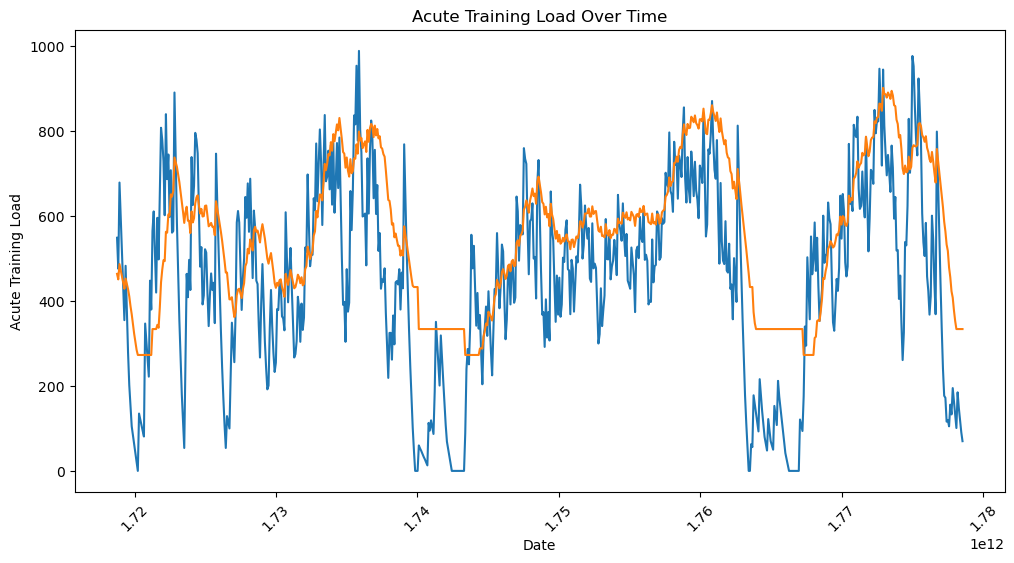

In [55]:
# Plot of acute trainig load over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='calendarDate', y='dailyTrainingLoadAcute', data=acute_training_load_df)
sns.lineplot(x='calendarDate', y='dailyTrainingLoadChronic', data=acute_training_load_df)
plt.title('Acute Training Load Over Time')
plt.xlabel('Date')
plt.ylabel('Acute Training Load')
plt.xticks(rotation=45)

In [56]:
print(acute_training_load_df.head())

   userProfilePK   calendarDate    deviceId      timestamp  acwrPercent  \
0       48001360  1718755200000  3476423097  1718859599000           47   
1       48001360  1718841600000  3476423097  1718945999000           42   
2       48001360  1718928000000  3476423097  1719032399000           57   
3       48001360  1719014400000  3476423097  1719118799000           52   
4       48001360  1719100800000  3476423097  1719205199000           47   

  acwrStatus acwrStatusFeedback  dailyTrainingLoadAcute  \
0    OPTIMAL         FEEDBACK_2                     549   
1    OPTIMAL         FEEDBACK_2                     476   
2    OPTIMAL         FEEDBACK_3                     679   
3    OPTIMAL         FEEDBACK_2                     598   
4    OPTIMAL         FEEDBACK_2                     517   

   dailyTrainingLoadChronic  dailyAcuteChronicWorkloadRatio       date  
0                       464                             1.1 2024-06-19  
1                       451                     

It appears as though this file contains data from 2024-06-19 -- 2024-07-12

Will now look at the next file with that tag.